In [2]:
import yaml
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


mdlColors = {
    'gb':   'thistle',
    'mm':   'tab:blue',
    'dft':  'k',
    'gbx':  'orange',
    'gbxx': 'orange',
    'mmx':  'orange'}

def loadPMF(file):
    if os.path.isfile(file):
        data = np.loadtxt(file)
        print(f'Loaded: {file}')
        return data
    else:
        print(f'NOT FOUND: {file}')  
        return file
    
def coulomb(r0, rmax, qprod, eps=78.5):
    rList = np.linspace(r0, rmax, 100)
    e = 1.6e-19
    nm = 1e-9
    A = 6.022e23
    k_kCal = 1/(4 * np.pi * 8.854187817e-12) / 4.184e3
    const = k_kCal * e**2 / nm * A
    return rList, const * qprod / (eps * rList)

def setZero(c,G,c0, G0=0):
    zero_ndx=min(range(len(c)), key=lambda i: abs(c[i]-c0)) #np.where(c==c0)[0][0]
    G_offset=[G[i]-G[zero_ndx]+G0 for i in range(len(G))]
    return G_offset

# def fillDifference(r1, G1, r2, G2):
#     r_min = max(min(r1), min(r2))
#     r_max = min(max(r1), max(r2))
#     r_common = np.linspace(r_min, r_max, 100)
#     G1_common = np.interp(r_common, r1, G1)
#     G2_common = np.interp(r_common, r2, G2)
#     G_diff = [G1_common[i]-G2_common[i] for i in range(len(r_common))]
#     return r_common, G2_common, G_diff

In [3]:
dirList = os.listdir('data/')
for i, pair in enumerate(dirList):
    if "-" not in pair: continue
    print(i, pair)


0 dma-na
1 ace-ace
2 na-ca
3 ace-ca
4 ace-dma
5 na-na
6 ca-cl
7 ace-na
8 dma-ca
9 na-cl
10 dma-dma
11 ace-cl
12 ca-ca
13 dma-cl
14 cl-cl


In [4]:
with open("/Users/yasmene/rc/gbx-graphs/data/ace-ca/about.yml") as stream:
    aboutInfo = yaml.safe_load(stream)
qprod = aboutInfo['A']['charge'] * aboutInfo['B']['charge']

sysTitle = aboutInfo['A']['name'] + " - " + aboutInfo['B']['name']
print("System:", sysTitle)

for method in ['gb', 'mm', 'dft', 'gbx', 'gbxx', 'mmx']:
    # Load PMF data
    if aboutInfo[method] == None: continue
    pmfFile = aboutInfo[method]['path']
    pmfData = loadPMF(pmfFile)
    aboutInfo[method]['pmfData'] = pmfData
    # Load diff data
    try: 
        diffFile = aboutInfo[method]['diffPath']
        diffData = loadPMF(diffFile)
        aboutInfo[method]['diffData'] = diffData
    except KeyError: aboutInfo[method]['diffData'] = None

System: Acetate - Calcium
Loaded: data/ace-ca/pmf-gb.dat
Loaded: data/ace-ca/pmf-mm.dat
Loaded: data/ace-ca/pmf-dft.dat
Loaded: data/ace-ca/diff-gbx.dat
Loaded: data/ace-ca/diff-gbx.dat
Loaded: data/ace-ca/diff-gbxx.dat
Loaded: data/ace-ca/diff-gbxx.dat
Loaded: data/ace-ca/diff-mmx.dat
Loaded: data/ace-ca/diff-mmx.dat


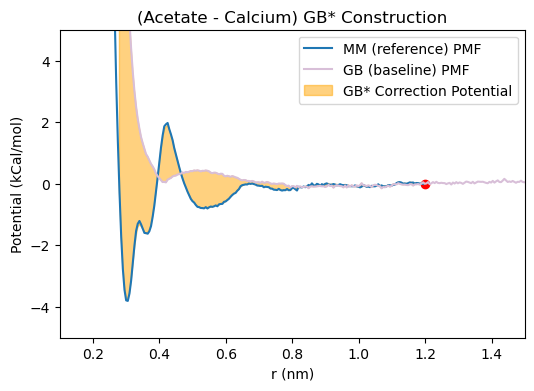

In [17]:
# Plot GB*
plt.figure(figsize=(6,4))
mdl = 'gbx'
r0 = aboutInfo[mdl]['mm_rMax']

# Plot MM
r_mm, mmPMF = aboutInfo['mm']['pmfData'][:,0], aboutInfo['mm']['pmfData'][:,1]
mmPMF = np.array(setZero(r_mm, mmPMF, r0))
imax = min(range(len(r_mm)), key=lambda i: abs(r_mm[i]-r0))
# plt.plot(r_mm, mmPMF, label='MM', color=mdlColors['mm'])
plt.plot(r_mm[:imax], mmPMF[:imax], label='MM (reference) PMF', color=mdlColors['mm'])
plt.scatter(r_mm[imax], mmPMF[imax], color='r', marker='o')

# Plot GB
r_gb, gbPMF = aboutInfo['gb']['pmfData'][:,0], aboutInfo['gb']['pmfData'][:,1]
gbPMF = np.array(setZero(r_gb, gbPMF, r0))
plt.plot(r_gb, gbPMF, label='GB (baseline) PMF', color=mdlColors['gb'])

# # Plot Coulomb
# r, coulV = coulomb(0.18, 1.55, qprod)
# coulV = setZero(r, coulV, r0)
# plt.plot(r, coulV, label='Coulomb', color='tab:grey', linestyle='--')

# Fill in difference
rdiff, diff = aboutInfo[mdl]['diffData'][:,0], aboutInfo[mdl]['diffData'][:,1]
diff_fn = interp1d(rdiff, diff, bounds_error=False, fill_value=np.nan)
mask = (r_gb >= rdiff.min()) & (r_gb <= rdiff.max())
rdiff = r_gb[mask]
plt.fill_between(rdiff, gbPMF[mask], gbPMF[mask] + diff_fn(rdiff), 
                 color=mdlColors[mdl], alpha=0.5, label='GB* Correction Potential')

plt.xlabel('r (nm)')
plt.ylabel('Potential (kCal/mol)')
if qprod > 0: plt.ylim(-2,8)
else: plt.ylim(-5, 5)
plt.xlim(0.1, 1.5)
plt.legend()
plt.title("("+sysTitle + ") GB* Construction")
plt.savefig('/Users/yasmene/OneDrive/UW research/Thesis/GBStar images/ace-ca-gbx-diff.pdf', bbox_inches='tight')
plt.show()



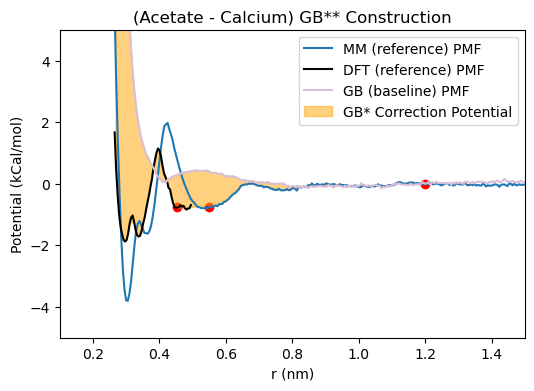

In [18]:
# Plot GB**
plt.figure(figsize=(6,4))
mdl = 'gbxx'
r0 = aboutInfo[mdl]['mm_rMax']
r1 = aboutInfo[mdl]['mm_rMin']
r2 = aboutInfo[mdl]['dft_rMax']

# Plot MM
r_mm, mmPMF = aboutInfo['mm']['pmfData'][:,0], aboutInfo['mm']['pmfData'][:,1]
mmPMF = np.array(setZero(r_mm, mmPMF, r0))
imax = min(range(len(r_mm)), key=lambda i: abs(r_mm[i]-r0))
imin = min(range(len(r_mm)), key=lambda i: abs(r_mm[i]-r1))
plt.plot(r_mm, mmPMF, label='MM (reference) PMF', color=mdlColors['mm'])
# plt.plot(r_mm[imin:imax], mmPMF[imin:imax], label='MM (reference) PMF', color=mdlColors['mm'])
plt.scatter(r0, mmPMF[imax], color='r', marker='o')
plt.scatter(r1, mmPMF[imin], color='r', marker='o')

# Plot DFT
r_dft, dftPMF = aboutInfo['dft']['pmfData'][:,0], aboutInfo['dft']['pmfData'][:,1]
dftPMF = np.array(setZero(r_dft, dftPMF, r2, G0=mmPMF[imin]))
imax = min(range(len(r_dft)), key=lambda i: abs(r_dft[i]-r2))
# plt.plot(r_dft, dftPMF, label='DFT (reference) PMF', color=mdlColors['dft'])
plt.plot(r_dft[:imax+10], dftPMF[:imax+10], label='DFT (reference) PMF', color=mdlColors['dft'])
plt.scatter(r2, dftPMF[imax], color='r', marker='o')


# Plot GB
r_gb, gbPMF = aboutInfo['gb']['pmfData'][:,0], aboutInfo['gb']['pmfData'][:,1]
gbPMF = np.array(setZero(r_gb, gbPMF, r0))
plt.plot(r_gb, gbPMF, label='GB (baseline) PMF', color=mdlColors['gb'])

# # Plot Coulomb
# r, coulV = coulomb(0.18, 1.55, qprod)
# coulV = setZero(r, coulV, r0)
# plt.plot(r, coulV, label='Coulomb', color='tab:grey', linestyle='--')

# Fill in difference
rdiff, diff = aboutInfo[mdl]['diffData'][:,0], aboutInfo[mdl]['diffData'][:,1]
diff_fn = interp1d(rdiff, diff, bounds_error=False, fill_value=np.nan)
mask = (r_gb >= rdiff.min()) & (r_gb <= rdiff.max())
rdiff = r_gb[mask]
plt.fill_between(rdiff, gbPMF[mask], gbPMF[mask] + diff_fn(rdiff), 
                 color=mdlColors[mdl], alpha=0.5, label='GB* Correction Potential')

plt.xlabel('r (nm)')
plt.ylabel('Potential (kCal/mol)')
if qprod > 0: plt.ylim(-2,8)
else: plt.ylim(-5, 5)
plt.xlim(0.1, 1.5)
plt.legend()
plt.title("("+sysTitle + ") GB** Construction")
plt.savefig('/Users/yasmene/OneDrive/UW research/Thesis/GBStar images/ace-ca-gbxx-diff.pdf', bbox_inches='tight')
plt.show()



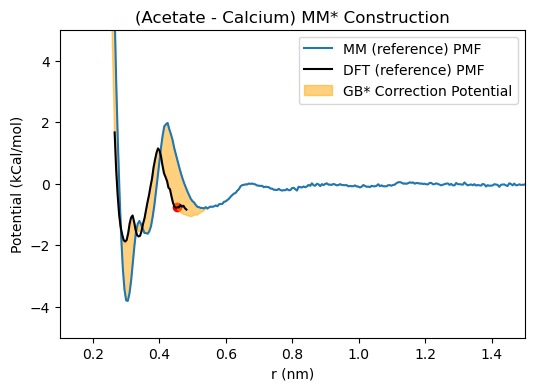

In [19]:
# Plot MM*
plt.figure(figsize=(6,4))
mdl = 'mmx'
r2 = aboutInfo[mdl]['dft_rMax']

# Plot MM
r_mm, mmPMF = aboutInfo['mm']['pmfData'][:,0], aboutInfo['mm']['pmfData'][:,1]
mmPMF = np.array(setZero(r_mm, mmPMF, r0))
plt.plot(r_mm, mmPMF, label='MM (reference) PMF', color=mdlColors['mm'])

# Plot DFT
r_dft, dftPMF = aboutInfo['dft']['pmfData'][:,0], aboutInfo['dft']['pmfData'][:,1]
dftPMF = np.array(setZero(r_dft, dftPMF, r2, G0=mmPMF[imin]))
imax = min(range(len(r_dft)), key=lambda i: abs(r_dft[i]-r2))
# plt.plot(r_dft, dftPMF, label='DFT', color=mdlColors['dft'])
plt.plot(r_dft[:imax+7], dftPMF[:imax+7], label='DFT (reference) PMF', color=mdlColors['dft'])
plt.scatter(r2, dftPMF[imax], color='r', marker='o')

# # Plot Coulomb
# r, coulV = coulomb(0.18, 1.55, qprod)
# coulV = setZero(r, coulV, r0)
# plt.plot(r, coulV, label='Coulomb', color='tab:grey', linestyle='--')

# Fill in difference
rdiff, diff = aboutInfo[mdl]['diffData'][:,0], aboutInfo[mdl]['diffData'][:,1]
diff_fn = interp1d(rdiff, diff, bounds_error=False, fill_value=np.nan)
mask = (r_mm >= rdiff.min()) & (r_mm <= rdiff.max())
rdiff = r_mm[mask]
plt.fill_between(rdiff, mmPMF[mask], mmPMF[mask] + diff_fn(rdiff), 
                 color=mdlColors[mdl], alpha=0.5, label='GB* Correction Potential')

plt.xlabel('r (nm)')
plt.ylabel('Potential (kCal/mol)')
if qprod > 0: plt.ylim(-2,8)
else: plt.ylim(-5, 5)
plt.xlim(0.1, 1.5)
plt.legend()
plt.title("("+sysTitle + ") MM* Construction")
plt.savefig('/Users/yasmene/OneDrive/UW research/Thesis/GBStar images/ace-ca-mmx-diff.pdf', bbox_inches='tight')
plt.show()

